# Reconhecimento Facial para Fechadura Biométrica — FPGA DE2-115

**Disciplina:** ENGG52 — Laboratório Integrado I-A (UFBA)

Este notebook implementa o pipeline completo de reconhecimento facial:

1. Pré-processamento de imagens (CLAHE, Haar Cascade, Augmentation)
2. Organização e separação dos dados (Treino / Validação / Teste)
3. Construção e treinamento da Tiny-CNN com restrições de quantização Q1.7
4. Avaliação de métricas e calibração do threshold de confiança
5. Exportação dos pesos quantizados para arquivo `.mif` (FPGA)
6. Inferência em tempo real via webcam

**Premissa de dados:** as imagens brutas estão organizadas em `data/raw/classes/`, onde cada subpasta representa uma pessoa (classe). As imagens podem ter nomes e extensões quaisquer.

### 1. Importação das Bibliotecas

Importamos todas as dependências: OpenCV para processamento de imagens, TensorFlow/Keras para a rede neural, scikit-learn para métricas e matplotlib/seaborn para visualização. Os avisos verbosos são suprimidos para manter a saída limpa.

In [ ]:
import os
import random
import shutil
import json
import warnings
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import class_weight

# Supressão de avisos
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

%matplotlib inline

# Reprodutibilidade
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("Imports concluídos com sucesso.")

### 2. Configurações Globais

Definimos os caminhos do projeto e todos os hiperparâmetros do pipeline. O campo `CONFIDENCE_THRESHOLD` é o limiar de confiança usado na inferência: se a maior probabilidade do softmax ficar abaixo desse valor, a pessoa será considerada desconhecida.

In [16]:
# === Diretórios ===
PROJECT_ROOT = Path(os.getcwd())
DATA_DIR       = PROJECT_ROOT / "data"
RAW_CLASSES_DIR = DATA_DIR / "raw" / "classes"   # Pastas com imagens coloridas por pessoa
INTERIM_DIR    = DATA_DIR / "interim"
PROCESSED_DIR  = DATA_DIR / "processed"
MODELS_DIR     = PROJECT_ROOT / "models"
REPORTS_DIR    = PROJECT_ROOT / "reports"
EXPORT_DIR     = PROJECT_ROOT / "export"

# Criação automática das pastas
for d in [RAW_CLASSES_DIR, INTERIM_DIR, PROCESSED_DIR, MODELS_DIR, REPORTS_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# === Modelo ===
IMG_SIZE     = 32
CHANNELS     = 1
BATCH_SIZE   = 32
EPOCHS       = 150
LEARNING_RATE = 0.003
DROPOUT_RATE  = 0.1
EARLY_STOP_PATIENCE = 25

# === Quantização Q1.7 ===
QUANT_FRAC_BITS = 7
QAT_START_EPOCH = 80

# === Inferência ===
CONFIDENCE_THRESHOLD = 0.95

# === Pré-processamento ===
MAX_PHOTOS_PER_CLASS = 500    # Limite máximo de fotos por classe (evita classe dominante)
BALANCE_STRATEGY = "median"   # "median" ou "min" — define o alvo de balanceamento
MAX_AUG_MULTIPLIER = 3.0      # Máximo de augmentation = 3x as originais

# === Caminho fixo do modelo salvo ===
MODEL_PATH = MODELS_DIR / "tiny_cnn_final.h5"

print(f"Dados brutos esperados em: {RAW_CLASSES_DIR}")
print(f"Modelo será salvo em:      {MODEL_PATH}")

Dados brutos esperados em: /run/media/gwolfovitch/Data/Lab1/data/raw/classes
Modelo será salvo em:      /run/media/gwolfovitch/Data/Lab1/models/tiny_cnn_final.h5


### 3. Funções de Pré-processamento

Duas funções essenciais:

- **`detect_and_crop`**: recebe uma imagem colorida (BGR), converte para escala de cinza, aplica o **CLAHE** (equalização adaptativa de histograma) para normalizar a iluminação, detecta o rosto com **Haar Cascade** e recorta com 15% de margem ao redor do rosto. O resultado é uma imagem 32×32 em escala de cinza.

- **`apply_augmentation`**: recebe uma face 32×32 já recortada e aplica transformações aleatórias (rotação, flip horizontal, zoom, variação de brilho) para gerar exemplos sintéticos de treino.

In [3]:
# Classificador Haar Cascade para detecção facial
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def detect_and_crop(image_bgr, img_size=IMG_SIZE):
    """Detecta face em imagem BGR, aplica CLAHE e retorna crop 32x32 grayscale."""
    if image_bgr is None:
        return None

    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    # CLAHE — normalização adaptativa de iluminação
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    # Detecção facial com os mesmos parâmetros usados no pipeline original
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(60, 60))

    for (x, y, w, h) in faces:
        # Recorte com 15% de margem (padding)
        pad = int(w * 0.15)
        y1 = max(0, y - pad)
        y2 = min(gray.shape[0], y + h + pad)
        x1 = max(0, x - pad)
        x2 = min(gray.shape[1], x + w + pad)
        roi = gray[y1:y2, x1:x2]
        return cv2.resize(roi, (img_size, img_size))

    return None


def apply_augmentation(image_gray, img_size=IMG_SIZE):
    """Aplica transformações aleatórias para data augmentation."""
    img = image_gray.copy()

    # Rotação leve (-15° a 15°)
    angle = random.randint(-15, 15)
    center = (img_size / 2, img_size / 2)
    M = cv2.getRotationMatrix2D(center, angle, 1)
    img = cv2.warpAffine(img, M, (img_size, img_size))

    # Espelhamento horizontal (50% de chance)
    if random.random() > 0.5:
        img = cv2.flip(img, 1)

    # Zoom aleatório (0.9x a 1.1x)
    zoom = random.uniform(0.9, 1.1)
    new_sz = int(img_size * zoom)
    img = cv2.resize(img, (new_sz, new_sz))
    if zoom > 1:
        start = (new_sz - img_size) // 2
        img = img[start:start + img_size, start:start + img_size]
    else:
        pad = (img_size - new_sz) // 2
        img = cv2.copyMakeBorder(
            img, pad, img_size - new_sz - pad,
            pad, img_size - new_sz - pad,
            cv2.BORDER_CONSTANT, value=0
        )

    # Variação de brilho/contraste
    alpha = random.uniform(0.8, 1.2)
    beta = random.randint(-20, 20)
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

print("Funções de pré-processamento definidas.")

Funções de pré-processamento definidas.


### 4. Construção do Dataset (Raw → Interim → Processed)

Esta célula realiza cinco passos para garantir um dataset **balanceado**:

1. **Detecção**: varre todas as pastas em `data/raw/classes/`, detecta faces em cada imagem
2. **Cálculo do alvo**: usa a **mediana** (ou mínimo) das contagens por classe como alvo — isso evita que uma classe com muitas fotos domine o treinamento
3. **Balanceamento**: classes acima do alvo são reduzidas (downsample aleatório); classes abaixo recebem augmentation (limitada a `MAX_AUG_MULTIPLIER` vezes as originais)
4. **Split**: divide em Treino (70%), Validação (10%) e Teste (20%)
5. **Mapa de classes**: salva em `models/class_indices.json`

O resultado é que **todas as classes terão aproximadamente a mesma quantidade de imagens**, independente de quantas fotos originais cada uma tinha.

In [4]:
# Limpar diretórios intermediários e processados
if INTERIM_DIR.exists():
    shutil.rmtree(INTERIM_DIR)
if PROCESSED_DIR.exists():
    shutil.rmtree(PROCESSED_DIR)
INTERIM_DIR.mkdir(parents=True)
PROCESSED_DIR.mkdir(parents=True)

valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}

# ══════════════════════════════════════════════════
# PASSO 1: Detectar TODAS as faces de TODAS as classes
# ══════════════════════════════════════════════════
print("=" * 55)
print("PASSO 1: Detectando faces em todas as classes")
print("=" * 55)

class_faces = {}  # {nome_classe: [face_array, ...]}

class_dirs = sorted([
    d for d in RAW_CLASSES_DIR.iterdir() if d.is_dir()
])

if not class_dirs:
    print(f"AVISO: Nenhuma subpasta encontrada em {RAW_CLASSES_DIR}")

for class_dir in class_dirs:
    class_name = class_dir.name
    image_files = [
        f for f in class_dir.rglob('*')
        if f.is_file() and f.suffix.lower() in valid_extensions
    ]

    faces = []
    for img_path in image_files:
        img_bgr = cv2.imdecode(np.fromfile(str(img_path), np.uint8), cv2.IMREAD_COLOR)
        face = detect_and_crop(img_bgr)
        if face is not None:
            faces.append(face)

    n = len(faces)
    print(f"  {class_name}: {len(image_files)} imagens → {n} faces detectadas")

    if n == 0:
        print(f"    AVISO: nenhuma face detectada, classe ignorada.")
        continue

    class_faces[class_name] = faces

if not class_faces:
    print("Nenhuma classe válida encontrada!")

# ══════════════════════════════════════════════════
# PASSO 2: Calcular alvo de balanceamento
# ══════════════════════════════════════════════════
print()
print("=" * 55)
print("PASSO 2: Balanceamento entre classes")
print("=" * 55)

counts = {name: len(faces) for name, faces in class_faces.items()}
count_values = sorted(counts.values())

if BALANCE_STRATEGY == "median":
    target = int(np.median(count_values))
elif BALANCE_STRATEGY == "min":
    target = min(count_values)
else:
    target = int(np.median(count_values))

# Aplicar o limite máximo por classe
target = min(target, MAX_PHOTOS_PER_CLASS)
# Garantir ao menos o mínimo
target = max(target, min(count_values))

print(f"  Contagem por classe: {counts}")
print(f"  Estratégia: {BALANCE_STRATEGY}")
print(f"  Alvo calculado: {target} fotos por classe")
print(f"  Limite máximo: {MAX_PHOTOS_PER_CLASS}")
print()

# ══════════════════════════════════════════════════
# PASSO 3: Salvar faces balanceadas (downsample ou augment)
# ══════════════════════════════════════════════════
print("=" * 55)
print("PASSO 3: Salvando faces balanceadas")
print("=" * 55)

for class_name, faces in class_faces.items():
    interim_class = INTERIM_DIR / class_name
    interim_class.mkdir(parents=True, exist_ok=True)
    n_orig = len(faces)

    if n_orig >= target:
        # Downsample: pegar apenas 'target' faces aleatórias
        selected = random.sample(faces, target)
        for i, face in enumerate(selected):
            cv2.imwrite(str(interim_class / f"orig_{i:04d}.jpg"), face)
        print(f"  {class_name}: {n_orig} originais → {target} selecionadas (downsample)")

    else:
        # Salvar todas as originais
        for i, face in enumerate(faces):
            cv2.imwrite(str(interim_class / f"orig_{i:04d}.jpg"), face)

        # Augmentar até o alvo (com limite de multiplicador)
        n_needed = target - n_orig
        max_aug = int(n_orig * MAX_AUG_MULTIPLIER)
        n_aug = min(n_needed, max_aug)

        for i in range(n_aug):
            aug = apply_augmentation(random.choice(faces))
            cv2.imwrite(str(interim_class / f"aug_{i:04d}.jpg"), aug)

        total = n_orig + n_aug
        print(f"  {class_name}: {n_orig} originais + {n_aug} aug = {total} total")

# ══════════════════════════════════════════════════
# PASSO 4: Split Treino / Validação / Teste
# ══════════════════════════════════════════════════
print()
print("=" * 55)
print("PASSO 4: Split Treino (70%) / Validação (10%) / Teste (20%)")
print("=" * 55)

for class_dir in sorted(INTERIM_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name

    all_files = list(class_dir.glob("*.jpg"))
    random.shuffle(all_files)
    n = len(all_files)

    if n == 0:
        continue

    i_train = int(0.7 * n)
    i_val   = i_train + max(1, int(0.1 * n))

    splits = {
        'train': all_files[:i_train],
        'val':   all_files[i_train:i_val],
        'test':  all_files[i_val:]
    }

    for split_name, files in splits.items():
        dest = PROCESSED_DIR / split_name / class_name
        dest.mkdir(parents=True, exist_ok=True)
        for f in files:
            shutil.copy(f, dest / f.name)

    print(f"  {class_name}: train={len(splits['train'])}  val={len(splits['val'])}  test={len(splits['test'])}")

# ══════════════════════════════════════════════════
# PASSO 5: Salvar mapa de classes
# ══════════════════════════════════════════════════
train_path = PROCESSED_DIR / 'train'
if train_path.exists():
    final_classes = sorted([d.name for d in train_path.iterdir() if d.is_dir()])
else:
    final_classes = []
class_map = {name: idx for idx, name in enumerate(final_classes)}

with open(MODELS_DIR / "class_indices.json", "w", encoding="utf-8") as f:
    json.dump(class_map, f, indent=2, ensure_ascii=False)

print(f"\nClasses finais ({len(final_classes)}): {final_classes}")
print(f"Mapa salvo em: {MODELS_DIR / 'class_indices.json'}")

PASSO 1: Detectando faces em todas as classes
  bruno: 1469 imagens → 822 faces detectadas
  gabriel: 1579 imagens → 1169 faces detectadas
  horacio: 538 imagens → 206 faces detectadas
  julia: 522 imagens → 120 faces detectadas
  lucio: 2690 imagens → 1274 faces detectadas
  rafael: 283 imagens → 57 faces detectadas
  yuri: 1741 imagens → 1153 faces detectadas

PASSO 2: Balanceamento entre classes
  Contagem por classe: {'bruno': 822, 'gabriel': 1169, 'horacio': 206, 'julia': 120, 'lucio': 1274, 'rafael': 57, 'yuri': 1153}
  Estratégia: median
  Alvo calculado: 500 fotos por classe
  Limite máximo: 500

PASSO 3: Salvando faces balanceadas
  bruno: 822 originais → 500 selecionadas (downsample)
  gabriel: 1169 originais → 500 selecionadas (downsample)
  horacio: 206 originais + 294 aug = 500 total
  julia: 120 originais + 360 aug = 480 total
  lucio: 1274 originais → 500 selecionadas (downsample)
  rafael: 57 originais + 171 aug = 228 total
  yuri: 1153 originais → 500 selecionadas (dow

### 5. Visualização das Faces Processadas

Exibimos uma amostra de 5 faces por classe do conjunto de treino. Isso permite verificar visualmente se o recorte está bem centralizado e a normalização de iluminação (CLAHE) está funcionando corretamente.

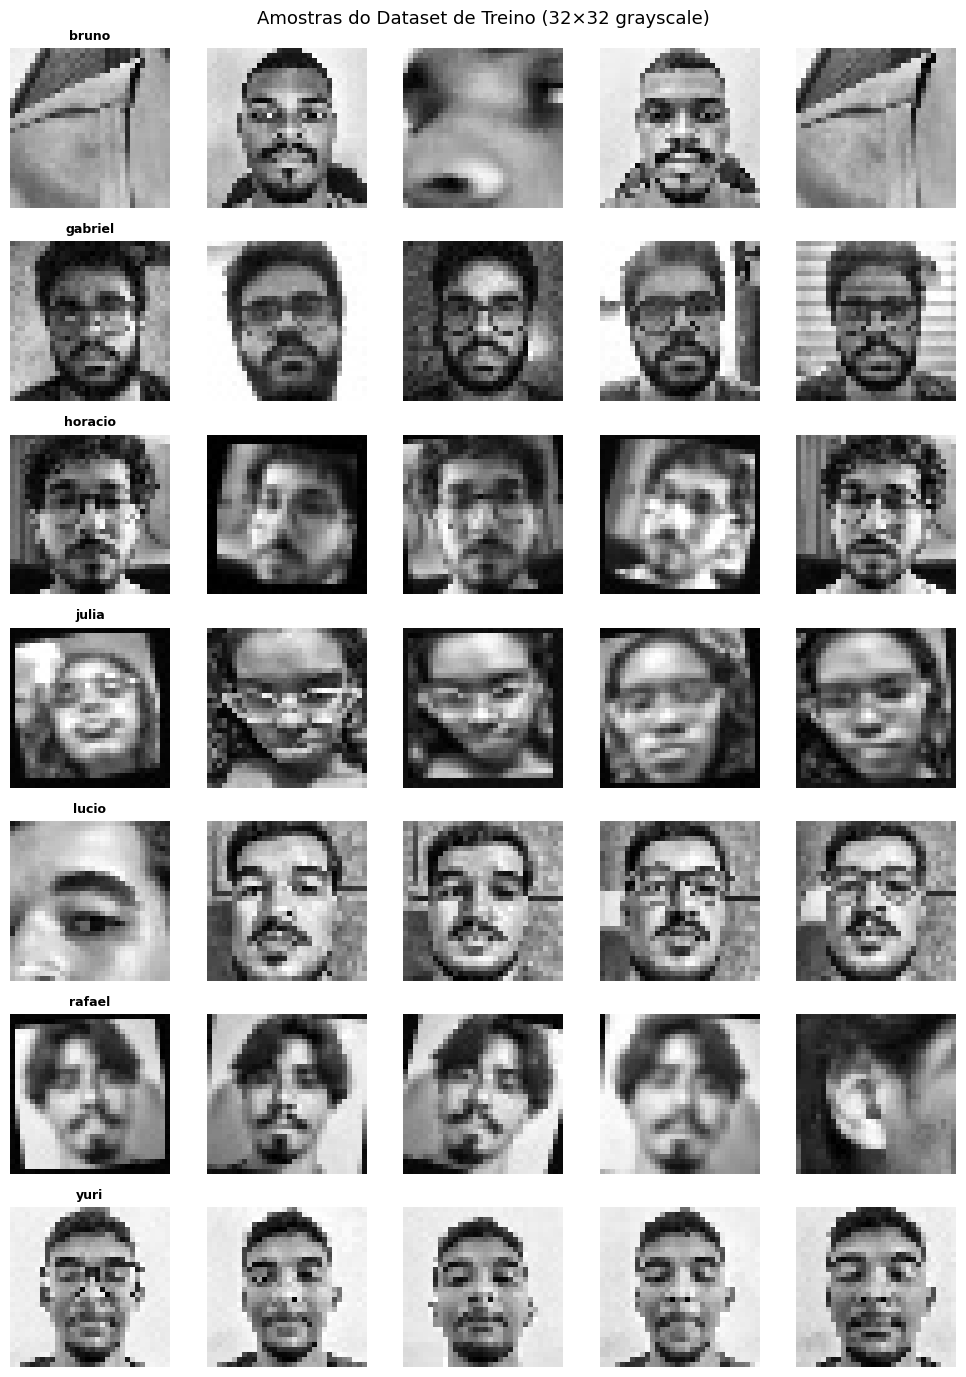

In [5]:
train_dir = PROCESSED_DIR / "train"
n_classes = len(final_classes)
n_cols = 5

if n_classes == 0:
    print("Nenhuma classe processada para visualizar.")
else:
    fig, axes = plt.subplots(n_classes, n_cols, figsize=(n_cols * 2, max(2, n_classes * 2)))

    # Garantir que axes é sempre 2D
    if n_classes == 1:
        axes = np.array([axes])

    # Desligar todos os axes primeiro
    for ax_row in axes:
        for ax in ax_row:
            ax.axis('off')

    for i, cname in enumerate(final_classes):
        c_dir = train_dir / cname
        imgs = list(c_dir.glob("*.jpg"))
        if not imgs:
            continue

        samples = random.sample(imgs, min(n_cols, len(imgs)))
        for j, img_path in enumerate(samples):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            axes[i, j].imshow(img, cmap='gray')
        axes[i, 0].set_title(cname, fontsize=9, fontweight='bold')

    plt.suptitle("Amostras do Dataset de Treino (32×32 grayscale)", fontsize=13)
    plt.tight_layout()
    plt.show()

### 6. Arquitetura da Tiny-CNN e Quantização Q1.7

A rede é propositalmente pequena para caber nos blocos de memória M9K da FPGA DE2-115:

```
Input (32×32×1) → Conv2D(4 filtros 3×3, ReLU) → MaxPool(2×2) → Flatten → Dropout → Dense(N, Softmax)
```

Para garantir que os pesos sejam compatíveis com aritmética de ponto fixo Q1.7 (8 bits: 1 sinal + 7 fracionários), aplicamos:

- **`Q17ClipConstraint`**: restringe os pesos ao intervalo [-1.0, +0.9921875] durante o treino.
- **`Q17WeightQuantizationCallback`**: a partir da época `QAT_START_EPOCH`, arredonda os pesos para os valores discretos Q1.7 ao final de cada época (Quantization-Aware Training).

In [6]:
@tf.keras.utils.register_keras_serializable(package="Lab1")
class Q17ClipConstraint(tf.keras.constraints.Constraint):
    """Restringe pesos ao intervalo representável por Q1.7."""
    def __init__(self, frac_bits=7):
        self.frac_bits = frac_bits
        self.min_val = -1.0
        self.max_val = (2 ** frac_bits - 1) / (2 ** frac_bits)

    def __call__(self, w):
        return tf.clip_by_value(w, self.min_val, self.max_val)

    def get_config(self):
        return {"frac_bits": self.frac_bits}


class Q17WeightQuantizationCallback(tf.keras.callbacks.Callback):
    """Callback de QAT: arredonda pesos para Q1.7 a partir de start_epoch."""
    def __init__(self, frac_bits=7, start_epoch=0):
        super().__init__()
        self.frac_bits = frac_bits
        self.start_epoch = start_epoch
        self.scale = float(2 ** frac_bits)
        self.min_val = -1.0
        self.max_val = (2 ** frac_bits - 1) / (2 ** frac_bits)

    def on_epoch_end(self, epoch, logs=None):
        if epoch >= self.start_epoch:
            for var in self.model.trainable_variables:
                clipped = tf.clip_by_value(var, self.min_val, self.max_val)
                quantized = tf.round(clipped * self.scale) / self.scale
                var.assign(quantized)


def build_tiny_cnn(num_classes):
    """Constrói a Tiny-CNN compatível com FPGA DE2-115."""
    constraint = Q17ClipConstraint(frac_bits=QUANT_FRAC_BITS)

    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)),
        layers.Conv2D(4, (3, 3), activation='relu', padding='valid',
                      kernel_initializer='he_normal',
                      kernel_constraint=constraint,
                      bias_constraint=constraint,
                      name='conv2d_hardware'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(num_classes, activation='softmax',
                     kernel_constraint=constraint,
                     bias_constraint=constraint,
                     name='dense_output')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
    )
    return model

print("Modelo e quantização definidos.")

Modelo e quantização definidos.


### 7. Treinamento

O treinamento usa:
- **Class weights balanceados** (calculados automaticamente pelo scikit-learn) para compensar eventuais diferenças de quantidade entre as classes.
- **EarlyStopping** monitorando `val_loss` com paciência de 25 épocas — interrompe o treino se a rede parar de melhorar.
- **QAT Callback** que arredonda os pesos para Q1.7 a partir da época 80, reduzindo a discrepância entre o modelo float e o modelo quantizado final.
- **Data augmentation online** (rotação, brilho) aplicada apenas ao conjunto de treino.

In [7]:
# Generators com augmentation no treino, sem augmentation na validação
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    brightness_range=[0.7, 1.3],
    horizontal_flip=False
)
val_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    PROCESSED_DIR / 'train',
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    PROCESSED_DIR / 'val',
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=BATCH_SIZE,
    shuffle=False
)

num_classes = train_gen.num_classes
print(f"Classes detectadas pelo generator: {num_classes}")
print(f"Mapeamento: {train_gen.class_indices}")

assert num_classes >= 2, "São necessárias pelo menos 2 classes para treinar o modelo."

# Pesos para balanceamento
labels = train_gen.classes
weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
cw = {int(k): float(v) for k, v in enumerate(weights)}
print(f"Class weights: {cw}")

# Construção do modelo
model = build_tiny_cnn(num_classes)
model.summary()

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True
    ),
    Q17WeightQuantizationCallback(
        frac_bits=QUANT_FRAC_BITS,
        start_epoch=QAT_START_EPOCH
    )
]

# Treinamento
print("\nIniciando treinamento...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=cw,
    callbacks=callbacks
)

# Guardar cópia dos pesos FP32 (pré-quantização) para validação posterior
print("\nSalvando pesos FP32 para validação de quantização...")
fp32_weights = [layer.get_weights() for layer in model.layers]

# Aplicar quantização Q1.7 final nos pesos (garante alinhamento com FPGA,
# mesmo que EarlyStopping tenha restaurado pesos de antes do QAT_START_EPOCH)
print("Aplicando quantização Q1.7 final nos pesos...")
frac = QUANT_FRAC_BITS
q_scale = float(2 ** frac)
q_min = -1.0
q_max = (2 ** frac - 1) / (2 ** frac)
for layer in model.layers:
    new_w = []
    for w in layer.get_weights():
        clipped = np.clip(w, q_min, q_max)
        quantized = np.round(clipped * q_scale) / q_scale
        new_w.append(quantized)
    if new_w:
        layer.set_weights(new_w)

# Salvar modelo (pesos já quantizados)
model.save(str(MODEL_PATH))
print(f"Modelo salvo em: {MODEL_PATH}")

Found 2245 images belonging to 7 classes.
Found 320 images belonging to 7 classes.
Classes detectadas pelo generator: 7
Mapeamento: {'bruno': 0, 'gabriel': 1, 'horacio': 2, 'julia': 3, 'lucio': 4, 'rafael': 5, 'yuri': 6}
Class weights: {0: 0.9163265306122449, 1: 0.9163265306122449, 2: 0.9163265306122449, 3: 0.9545068027210885, 4: 0.9163265306122449, 5: 2.0170709793351302, 6: 0.9163265306122449}


E0000 00:00:1778538121.185389  123520 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778538121.185612  125367 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778538121.212411  123520 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_hardware (Conv2D)        │ (None, 30, 30, 4)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 900)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 900)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 7)              │         6,307 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,347 (24.79 KB)

...

 Non-trainable params: 0 (0.00 B)


Iniciando treinamento...
Epoch 1/150


I0000 00:00:1778538121.424576  123520 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6334 - loss: 1.1422 - val_accuracy: 0.9000 - val_loss: 0.4570
Epoch 2/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8829 - loss: 0.4401 - val_accuracy: 0.9438 - val_loss: 0.1868
Epoch 3/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9203 - loss: 0.3134 - val_accuracy: 0.9406 - val_loss: 0.2029
Epoch 4/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9359 - loss: 0.2420 - val_accuracy: 0.9625 - val_loss: 0.1450
Epoch 5/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9510 - loss: 0.1968 - val_accuracy: 0.9594 - val_loss: 0.1402
Epoch 6/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9501 - loss: 0.1791 - val_accuracy: 0.9812 - val_loss: 0.0899
Epoch 7/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9608 - loss: 0.1524 - val_accuracy: 0.9812 - val_loss: 0.0877
Epoch 8/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9626 - loss: 0.1449 - val_accuracy: 0.9812 - val_l


Salvando pesos FP32 para validação de quantização...
Aplicando quantização Q1.7 final nos pesos...
Modelo salvo em: /run/media/gwolfovitch/Data/Lab1/models/tiny_cnn_final.h5


### 8. Curvas de Treinamento (Loss e Acurácia)

Plotamos a evolução da loss e da acurácia ao longo das épocas para verificar se houve convergência adequada e se não há sinais de overfitting (quando a curva de treino continua melhorando mas a de validação estagna ou piora).

Gráficos salvos em: /run/media/gwolfovitch/Data/Lab1/reports/historico_treinamento.png


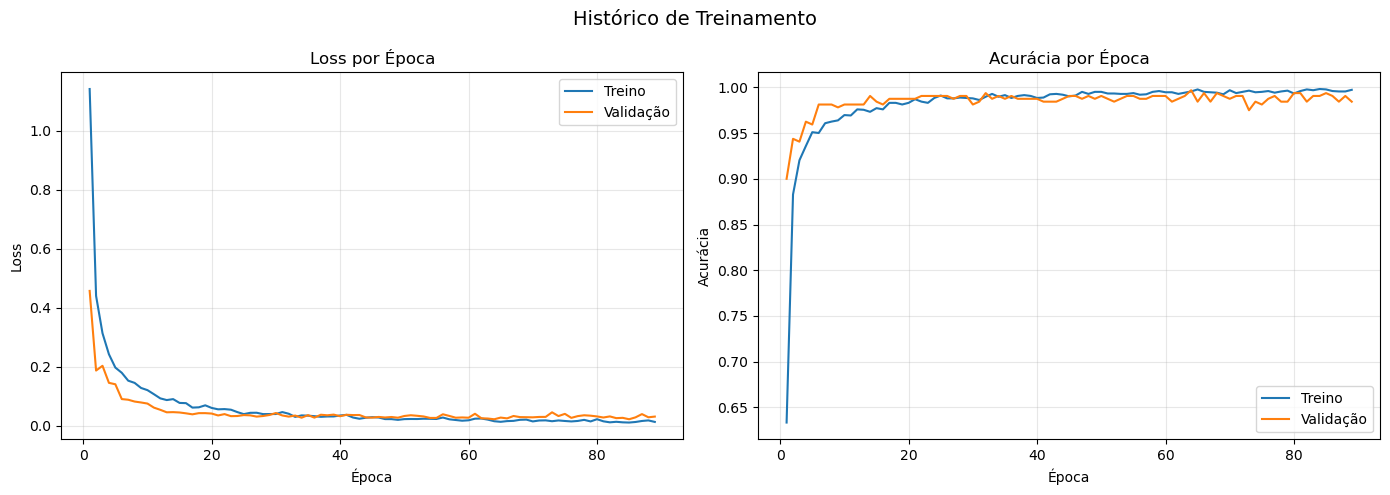

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history['loss']) + 1)

# Loss
ax1.plot(epochs_range, history.history['loss'], label='Treino')
ax1.plot(epochs_range, history.history['val_loss'], label='Validação')
ax1.set_title('Loss por Época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Acurácia
ax2.plot(epochs_range, history.history['accuracy'], label='Treino')
ax2.plot(epochs_range, history.history['val_accuracy'], label='Validação')
ax2.set_title('Acurácia por Época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Histórico de Treinamento', fontsize=14)
plt.tight_layout()

fig.savefig(str(REPORTS_DIR / "historico_treinamento.png"), dpi=150)
print(f"Gráficos salvos em: {REPORTS_DIR / 'historico_treinamento.png'}")
plt.show()

### 9. Avaliação no Conjunto de Teste

Avaliamos o modelo no subconjunto de teste (nunca visto durante o treinamento). Geramos:
- **Relatório de classificação** (precision, recall, f1-score por classe)
- **Matriz de confusão** para identificar quais classes estão sendo confundidas

Found 643 images belonging to 7 classes.
RELATÓRIO DE CLASSIFICAÇÃO (TESTE)
              precision    recall  f1-score   support

       bruno       1.00      0.99      0.99       100
     gabriel       0.98      0.97      0.97       100
     horacio       1.00      1.00      1.00       100
       julia       1.00      1.00      1.00        96
       lucio       0.97      0.99      0.98       100
      rafael       1.00      1.00      1.00        47
        yuri       0.99      0.99      0.99       100

    accuracy                           0.99       643
   macro avg       0.99      0.99      0.99       643
weighted avg       0.99      0.99      0.99       643

Macro-F1:          0.9914
Balanced Accuracy: 0.9914
AUC OvR (macro):   0.9999



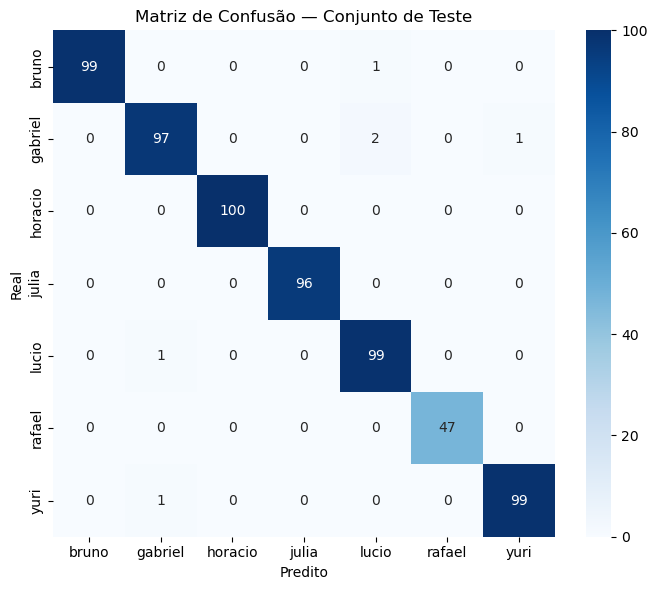

In [9]:
test_gen = val_datagen.flow_from_directory(
    PROCESSED_DIR / 'test',
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Predições
y_pred_prob = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes
test_class_names = list(test_gen.class_indices.keys())

# Relatório
print("=" * 50)
print("RELATÓRIO DE CLASSIFICAÇÃO (TESTE)")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=test_class_names, zero_division=0))

# Métricas agregadas
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score

macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
bal_acc = balanced_accuracy_score(y_true, y_pred)

try:
    if num_classes == 2:
        auc_ovr = roc_auc_score(y_true, y_pred_prob[:, 1])
    else:
        auc_ovr = roc_auc_score(y_true, y_pred_prob, average='macro', multi_class='ovr')
    auc_str = f"{auc_ovr:.4f}"
except ValueError as e:
    auc_ovr = None
    auc_str = f"N/A ({e})"

print(f"Macro-F1:          {macro_f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"AUC OvR (macro):   {auc_str}")
print()

# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(max(6, num_classes), max(5, num_classes - 1)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_class_names, yticklabels=test_class_names)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão — Conjunto de Teste')
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "matriz_confusao.png"), dpi=150)
plt.show()

### 10. Análise de Threshold de Confiança

Como **não existe** uma classe treinada de "desconhecidos", a rejeição de invasores é feita pelo **threshold de confiança**: se a maior probabilidade do softmax for menor que o limiar, a pessoa é considerada desconhecida.

Abaixo analisamos como diferentes valores de threshold afetam:
- A **acurácia** entre as amostras que passam pelo filtro
- A **taxa de rejeição** (percentual de amostras descartadas)

Isso ajuda a calibrar o `CONFIDENCE_THRESHOLD` de forma informada.

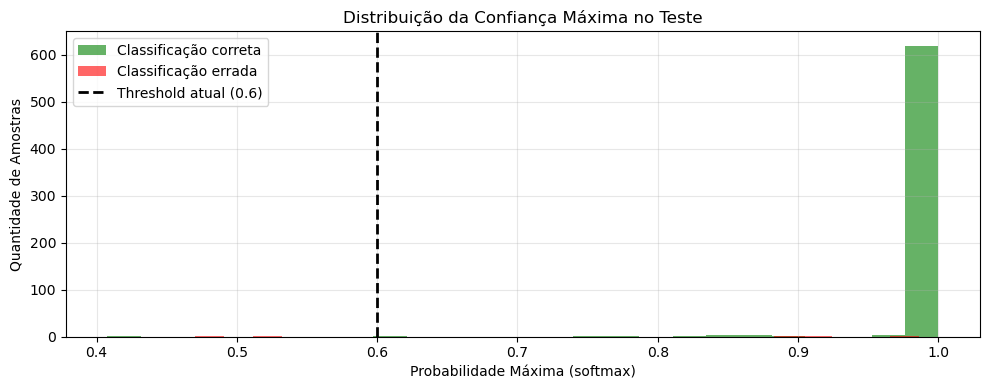

 Threshold |   Acurácia (aceitos) |   Taxa de rejeição
-------------------------------------------------------
      0.30 |                99.1% |               0.0%
      0.40 |                99.1% |               0.0%
      0.50 |                99.4% |               0.5%
      0.60 |                99.5% |               0.6% ◄
      0.70 |                99.5% |               0.9%
      0.80 |                99.5% |               1.4%
      0.90 |                99.7% |               2.8%
      0.95 |                99.8% |               3.0%


In [10]:
max_probs = np.max(y_pred_prob, axis=1)
acertos = (y_pred == y_true)

# Histograma da confiança
plt.figure(figsize=(10, 4))
plt.hist(max_probs[acertos], bins=25, alpha=0.6, color='green', label='Classificação correta')
plt.hist(max_probs[~acertos], bins=25, alpha=0.6, color='red', label='Classificação errada')
plt.axvline(CONFIDENCE_THRESHOLD, color='black', linestyle='dashed', linewidth=2,
            label=f'Threshold atual ({CONFIDENCE_THRESHOLD})')
plt.title('Distribuição da Confiança Máxima no Teste')
plt.xlabel('Probabilidade Máxima (softmax)')
plt.ylabel('Quantidade de Amostras')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tabela de análise por threshold
print(f"{'Threshold':>10} | {'Acurácia (aceitos)':>20} | {'Taxa de rejeição':>18}")
print("-" * 55)
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    aceitos = max_probs >= t
    n_aceitos = np.sum(aceitos)
    if n_aceitos > 0:
        acc = np.mean(acertos[aceitos]) * 100
    else:
        acc = 0.0
    rej = (1.0 - np.mean(aceitos)) * 100
    marker = " ◄" if t == CONFIDENCE_THRESHOLD else ""
    print(f"{t:>10.2f} | {acc:>19.1f}% | {rej:>17.1f}%{marker}")

### 11. Validação de Degradação por Quantização (FP32 vs Q1.7)

Verificamos o impacto da quantização Q1.7 na qualidade do modelo. O procedimento:

1. Restaura os pesos FP32 (salvos antes da quantização na célula de treinamento) e gera predições de referência
2. Carrega o modelo quantizado Q1.7 (salvo em disco) e gera predições quantizadas
3. Compara ambos os conjuntos de predições no conjunto de teste

Se a degradação for mínima (< 1%), os pesos estão seguros para exportação à FPGA.

In [11]:
# Validação de quantização Q1.7
# Compara o modelo com pesos FP32 originais vs o modelo com pesos Q1.7 finais
print("=" * 60)
print("VALIDAÇÃO: FP32 (pré-quantização) vs Q1.7 (pós-quantização)")
print("=" * 60)

# Restaurar pesos FP32 temporariamente para gerar predições de referência
for layer, fp32_w in zip(model.layers, fp32_weights):
    if fp32_w:
        layer.set_weights(fp32_w)

test_gen.reset()
probs_fp32 = model.predict(test_gen, verbose=0)
y_pred_fp32 = np.argmax(probs_fp32, axis=1)

# Restaurar pesos Q1.7 (recarregando do disco)
model_q17 = keras.models.load_model(
    str(MODEL_PATH),
    custom_objects={"Q17ClipConstraint": Q17ClipConstraint},
    compile=False
)

test_gen.reset()
probs_q17 = model_q17.predict(test_gen, verbose=0)
y_pred_q17 = np.argmax(probs_q17, axis=1)

# Restaurar pesos Q1.7 no modelo principal (para que as células seguintes usem a versão final)
model = model_q17

# Métricas comparativas
acc_fp32 = np.mean(y_pred_fp32 == y_true)
acc_q17 = np.mean(y_pred_q17 == y_true)
f1_fp32 = f1_score(y_true, y_pred_fp32, average='macro', zero_division=0)
f1_q17 = f1_score(y_true, y_pred_q17, average='macro', zero_division=0)

pred_diff = np.abs(probs_fp32 - probs_q17)
changed = int(np.sum(y_pred_fp32 != y_pred_q17))

print(f"\n{'Métrica':<25} {'FP32':>10} {'Q1.7':>10} {'Degradação':>12}")
print("-" * 60)
print(f"{'Acurácia':<25} {acc_fp32:>10.4f} {acc_q17:>10.4f} {acc_fp32 - acc_q17:>11.4f}")
print(f"{'Macro-F1':<25} {f1_fp32:>10.4f} {f1_q17:>10.4f} {f1_fp32 - f1_q17:>11.4f}")
print(f"{'Diferença média (L1)':<25} {'-':>10} {'-':>10} {np.mean(pred_diff):>11.6f}")
print(f"{'Diferença máxima':<25} {'-':>10} {'-':>10} {np.max(pred_diff):>11.6f}")
print(f"{'Predições alteradas':<25} {'-':>10} {'-':>10} {changed}/{len(y_true)}")

# Veredicto
deg_acc = acc_fp32 - acc_q17
deg_f1 = f1_fp32 - f1_q17
print()
if deg_acc < 0.01 and deg_f1 < 0.01:
    print("✅ Quantização Q1.7 preserva a qualidade. Seguro para exportação FPGA.")
else:
    print("⚠️  Degradação acima de 1%. Considere ajustar QAT_START_EPOCH ou revisar os pesos.")

VALIDAÇÃO: FP32 (pré-quantização) vs Q1.7 (pós-quantização)

Métrica                         FP32       Q1.7   Degradação
------------------------------------------------------------
Acurácia                      0.9907     0.9907      0.0000
Macro-F1                      0.9914     0.9914      0.0000
Diferença média (L1)               -          -    0.000151
Diferença máxima                   -          -    0.044173
Predições alteradas                -          - 0/643

✅ Quantização Q1.7 preserva a qualidade. Seguro para exportação FPGA.


### 12. Exportação de Pesos Quantizados (.mif)

Convertemos os pesos do modelo para o formato **Q1.7** (ponto fixo de 8 bits) e geramos um arquivo `.mif` (Memory Initialization File) compatível com o Intel Quartus Prime, para carregamento nos blocos de memória M9K da FPGA DE2-115.

A conversão: `valor_fixo = round(valor_float × 128)`, limitado ao intervalo [-128, +127].

In [ ]:
def to_q17_hex(value, bit_width=8, frac_bits=7):
    """Converte float para representacao hexadecimal em Q1.7."""
    max_int = (2 ** (bit_width - 1)) - 1
    min_int = -(2 ** (bit_width - 1))
    fixed = int(np.round(value * (2 ** frac_bits)))
    fixed = max(min(fixed, max_int), min_int)
    if fixed < 0:
        fixed = (1 << bit_width) + fixed
    return format(fixed, f"0{bit_width // 4}X")


def export_model_to_mif(model, output_path=None):
    """Exporta pesos no layout esperado pelo weights_shared_rom.v."""
    conv_layer = model.get_layer("conv2d_hardware")
    dense_layer = model.get_layer("dense_output")

    conv_w, conv_b = conv_layer.get_weights()
    dense_w, dense_b = dense_layer.get_weights()

    if conv_w.shape[2] != 1:
        raise ValueError("Conv layer must have 1 input channel for this export.")

    if output_path is None:
        output_path = PROJECT_ROOT / "modulos_verilog" / "weights_all.mif"

    # Ordem esperada: filtros de convolucao (filtro-major), bias conv,
    # pesos densos (classe-major), bias denso.
    conv_list = []
    for f in range(conv_w.shape[3]):
        for r in range(conv_w.shape[0]):
            for c in range(conv_w.shape[1]):
                conv_list.append(conv_w[r, c, 0, f])
    conv_list.extend(conv_b.tolist())

    dense_list = []
    for c in range(dense_w.shape[1]):
        dense_list.extend(dense_w[:, c].tolist())
    dense_list.extend(dense_b.tolist())

    all_vals = np.array(conv_list + dense_list, dtype=np.float32)
    expected = conv_w.size + conv_b.size + dense_w.size + dense_b.size
    if len(all_vals) != expected:
        raise ValueError(f"Unexpected weight count: {len(all_vals)} != {expected}")

    lines = [
        f"DEPTH = {len(all_vals)};",
        "WIDTH = 8;",
        "ADDRESS_RADIX = DEC;",
        "DATA_RADIX = HEX;",
        "CONTENT BEGIN",
    ]
    for addr, val in enumerate(all_vals):
        lines.append(f"{addr} : {to_q17_hex(val)};")
    lines.append("END;")

    out_path = Path(output_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w") as f:
        f.write("\n".join(lines))

    print(f"Arquivo exportado: {out_path}")


export_model_to_mif(model)

Total de pesos: 6347 (6347 bytes em Q1.7)
Arquivo exportado: /run/media/gwolfovitch/Data/Lab1/export/all_weights_q17.mif


### 13. Inferência em Imagem Avulsa e Exportação para Testbench

Duas funções utilitárias:

- **`inferir(image_bgr)`**: classifica uma única imagem e retorna o nome da classe predita (ou "Desconhecido" se abaixo do threshold).

- **`exportar_face_hex(image_bgr, output_path)`**: detecta a face, pré-processa para 32×32 grayscale (mesmo pipeline do treino), e exporta os valores dos pixels em hexadecimal (1 valor por linha, 8 bits, ordem row-major) em um arquivo `.txt` pronto para servir de entrada ao testbench do FPGA.

Classe: gabriel | Confiança: 100.0%
Exportado: export/gabriel_tb.txt (1024 pixels, 32x32)


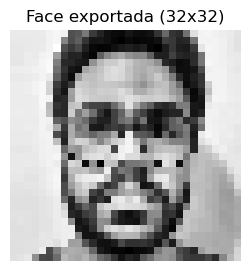

PosixPath('export/gabriel_tb.txt')

In [ ]:
def inferir(image_bgr, model=model, class_names=final_classes, threshold=CONFIDENCE_THRESHOLD):
    """
    Recebe uma imagem BGR e retorna o resultado da classificação.
    
    Args:
        image_bgr: imagem colorida (BGR) de qualquer resolução.
        model: modelo Keras carregado.
        class_names: lista ordenada dos nomes das classes.
        threshold: limiar mínimo de confiança.
    
    Retorna:
        dict com chaves: 'classe', 'confianca', 'face_crop'
    """
    face = detect_and_crop(image_bgr)
    
    if face is None:
        return {"classe": None, "confianca": 0.0, "face_crop": None}
    
    face_input = face.astype('float32') / 255.0
    face_input = np.expand_dims(face_input, axis=(0, -1))
    
    probs = model.predict(face_input, verbose=0)[0]  # type: ignore
    idx = int(np.argmax(probs))
    conf = float(probs[idx])
    
    if conf >= threshold:
        classe = class_names[idx]
    else:
        classe = "Desconhecido"
    
    return {"classe": classe, "confianca": conf, "face_crop": face}


# Exemplo de uso (descomente e ajuste o caminho):
resultado = inferir(cv2.imread("/run/media/gwolfovitch/Data/Lab1/data/raw/classes/gabriel/frame0.jpg"))
print(f"Classe: {resultado['classe']} | Confiança: {resultado['confianca']:.1%}")


def exportar_face_hex(image_bgr, output_path="inputs/teste2.txt", frac_bits=7):
    """
    Recebe uma imagem BGR, detecta a face, pre-processa (32x32 grayscale)
    e exporta os valores dos pixels em Q1.7 (8 bits, two's complement)
    para uso como entrada de testbench FPGA.

    Cada pixel e escrito em hex (1 valor por linha), ordem row-major
    (linha por linha, esquerda para direita, topo para baixo).
    Total: 1024 valores (32x32).

    Args:
        image_bgr: imagem colorida (BGR) de qualquer resolução.
        output_path: caminho do arquivo .txt de saída.
        frac_bits: bits fracionarios (default 7).

    Retorna:
        Path do arquivo gerado, ou None se nenhuma face foi detectada.
    """
    face = detect_and_crop(image_bgr)

    if face is None:
        print("Nenhuma face detectada na imagem.")
        return None

    face_norm = face.astype('float32') / 255.0

    out = Path(output_path)
    out.parent.mkdir(parents=True, exist_ok=True)

    with open(out, "w") as f:
        for row in range(face_norm.shape[0]):
            for col in range(face_norm.shape[1]):
                pixel = float(face_norm[row, col])
                f.write(f"{to_q17_hex(pixel, frac_bits=frac_bits)}\n")

    total = face.shape[0] * face.shape[1]
    print(f"Exportado: {out} ({total} pixels, {face.shape[0]}x{face.shape[1]})")

    # Mostrar preview
    plt.figure(figsize=(3, 3))
    plt.imshow(face, cmap='gray')
    plt.title(f"Face exportada ({face.shape[0]}x{face.shape[1]})")
    plt.axis('off')
    plt.show()

    return out


# Exemplo de uso:
exportar_face_hex(cv2.imread("/run/media/gwolfovitch/Data/Lab1/data/raw/classes/gabriel/frame0.jpg"), "inputs/teste2.txt")

### 14. Inferência em Tempo Real via Webcam

A função abaixo captura frames da câmera, detecta faces em cada frame usando o mesmo pipeline de pré-processamento do treino (CLAHE + Haar Cascade + padding 15%), e classifica cada rosto encontrado.

- Se a confiança máxima for **≥ threshold**: exibe o **nome da classe** (nome da pasta) em verde com bounding box.
- Se a confiança for **< threshold**: exibe "Desconhecido" em vermelho.

**Para executar**: descomente a última linha da próxima célula. Pressione `q` na janela de vídeo para encerrar.

In [17]:
def run_webcam_inference(model_path, class_names_list, threshold=CONFIDENCE_THRESHOLD):
    """
    Inferência em tempo real via webcam.
    Detecta faces, classifica e exibe o nome da classe ou 'Desconhecido'.
    """
    loaded_model = keras.models.load_model(
        str(model_path),
        custom_objects={"Q17ClipConstraint": Q17ClipConstraint},
        compile=False
    )

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Erro: não foi possível abrir a webcam.")
        return

    print("Webcam iniciada. Pressione 'q' na janela de vídeo para encerrar.")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Preprocessamento igual ao treino
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        gray_clahe = clahe.apply(gray)

        # Detecta todos os rostos no frame
        faces = face_cascade.detectMultiScale(gray_clahe, 1.2, 5, minSize=(60, 60))

        if len(faces) == 0:
            cv2.putText(frame, "Procurando rosto...", (30, 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

        for (x, y, w, h) in faces:
            # Recorte com 15% de padding (idêntico ao treino)
            pad = int(w * 0.15)
            y1 = max(0, y - pad)
            y2 = min(gray_clahe.shape[0], y + h + pad)
            x1 = max(0, x - pad)
            x2 = min(gray_clahe.shape[1], x + w + pad)

            face_roi = gray_clahe[y1:y2, x1:x2]
            if face_roi.size == 0:
                continue

            # Preparar para o modelo (32x32, normalizado)
            face_resized = cv2.resize(face_roi, (IMG_SIZE, IMG_SIZE))
            face_input = face_resized.astype('float32') / 255.0
            face_input = np.expand_dims(face_input, axis=(0, -1))

            # Predição
            probs = loaded_model.predict(face_input, verbose=0)[0]
            pred_idx = int(np.argmax(probs))
            pred_conf = float(probs[pred_idx])

            # Decisão baseada no threshold
            if pred_conf >= threshold:
                display_name = class_names_list[pred_idx]
                color = (0, 255, 0)   # Verde
            else:
                display_name = "Desconhecido"
                color = (0, 0, 255)   # Vermelho

            label = f"{display_name} ({pred_conf*100:.1f}%)"

            # Desenha bounding box e texto no frame
            cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
            cv2.putText(frame, label, (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            # Mini-visualização do que a rede vê
            cv2.imshow("Visao da CNN (32x32)", cv2.resize(face_resized, (160, 160)))

        cv2.imshow("Fechadura Biometrica", frame)

        if cv2.waitKey(20) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Webcam encerrada.")


# Descomente a linha abaixo para executar a inferência via webcam:
run_webcam_inference(MODEL_PATH, final_classes)

Webcam iniciada. Pressione 'q' na janela de vídeo para encerrar.
Webcam encerrada.
